# 11 -- Multi-label Output: TRUTHFUL / HALLUCINATED / UNCERTAIN
## LLM Lie Detector | Phase 6

This notebook extends the detector with a third output category: UNCERTAIN.
Rather than retraining, we use the calibrated confidence scores from notebook 08
to define principled thresholds for when the model should abstain from a
confident prediction.

### Goals
- Define UNCERTAIN as cases where confidence falls between 0.15 and 0.85
- Evaluate the three-class system on the validation set
- Measure how abstaining on uncertain cases improves precision on confident predictions
- Visualize the distribution of three-class predictions

### Design Decision
Threshold-based approach using existing confidence scores -- no retraining required.
UNCERTAIN does not mean "wrong", it means "the model lacks sufficient confidence
to make a reliable binary prediction and the case should be routed to human review."

In [1]:
import os
os.environ["PYTHONUTF8"] = "1"

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv('../.env')
login(token=os.getenv("HF_TOKEN"))

print("All imports successful.")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


All imports successful.
CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [2]:
model_id = "meta-llama/Llama-3.2-3B-Instruct"
adapter_id = "tamimmirza/llama-3.2-3b-hallucination-detector"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto"
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, adapter_id)
model.eval()

print(f"\nModel ready.")
print(f"VRAM: {torch.cuda.memory_allocated(0) / 1e9:.1f} GB")

Loading tokenizer...
Loading base model...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loading LoRA adapter...


W0513 01:24:37.255000 21780 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels



Model ready.
VRAM: 6.4 GB


In [3]:
df = pd.read_csv('../data/combined_dataset.csv')

_, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df['label']
)
val_df = val_df.reset_index(drop=True)

# Use same 200 samples as calibration for consistency
sample_df = val_df.sample(200, random_state=42).reset_index(drop=True)

print(f"Validation set: {len(val_df)} samples")
print(f"Working sample: {len(sample_df)} samples")
print(f"Label distribution:\n{sample_df['label'].value_counts()}")

Validation set: 1592 samples
Working sample: 200 samples
Label distribution:
label
1    104
0     96
Name: count, dtype: int64


In [4]:
def predict_three_class(question: str, answer: str,
                        uncertain_low: float = 0.15,
                        uncertain_high: float = 0.85) -> dict:
    """
    Three-class hallucination detector: TRUTHFUL / UNCERTAIN / HALLUCINATED.

    Uses token-level probability scores from the model's logits to assign
    a confidence score, then applies calibrated thresholds to determine
    whether the model is confident enough to make a binary prediction.

    Thresholds derived from calibration analysis in notebook 08:
        - Above 0.85: HIGH confidence HALLUCINATED (100% accurate in calibration)
        - Below 0.15: HIGH confidence TRUTHFUL (90% accurate in calibration)
        - Between 0.15 and 0.85: UNCERTAIN -- route to human review

    Args:
        question:      The original question.
        answer:        The LLM-generated answer to evaluate.
        uncertain_low: Lower confidence threshold for UNCERTAIN zone.
        uncertain_high: Upper confidence threshold for UNCERTAIN zone.

    Returns:
        dict with verdict (TRUTHFUL/UNCERTAIN/HALLUCINATED),
        confidence score, and threshold zone.
    """
    prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1, :]

    probs = torch.softmax(logits, dim=-1)

    # Get token probabilities for HALLUCINATED and TRUTHFUL
    hallucinated_id = tokenizer.encode("HALLUCINATED", add_special_tokens=False)[0]
    truthful_id = tokenizer.encode("TRUTHFUL", add_special_tokens=False)[0]

    prob_h = probs[hallucinated_id].item()
    prob_t = probs[truthful_id].item()

    # Normalize to relative confidence
    total = prob_h + prob_t
    confidence = prob_h / total if total > 0 else 0.5

    # Apply three-class thresholds
    if confidence >= uncertain_high:
        verdict = "HALLUCINATED"
        zone = "high_confidence"
    elif confidence <= uncertain_low:
        verdict = "TRUTHFUL"
        zone = "high_confidence"
    else:
        verdict = "UNCERTAIN"
        zone = "uncertain"

    return {
        "verdict": verdict,
        "confidence": confidence,
        "zone": zone,
    }

# Sanity check
test = predict_three_class(
    "Where did fortune cookies originate?",
    "Fortune cookies originated in China."
)
print(f"Verdict: {test['verdict']}")
print(f"Confidence: {test['confidence']:.4f}")
print(f"Zone: {test['zone']}")

Verdict: HALLUCINATED
Confidence: 0.9044
Zone: high_confidence


In [5]:
print("Running three-class prediction on 200 samples...")

three_class_results = []

for i, row in sample_df.iterrows():
    result = predict_three_class(row['question'], row['answer'])
    
    three_class_results.append({
        'question':     row['question'],
        'answer':       row['answer'],
        'true_label':   row['label'],
        'verdict':      result['verdict'],
        'confidence':   result['confidence'],
        'zone':         result['zone'],
    })
    
    if (i + 1) % 50 == 0:
        print(f"Progress: {i+1}/200 samples processed")

tcr_df = pd.DataFrame(three_class_results)
print(f"\nDone.")
print(f"\nVerdict distribution:")
print(tcr_df['verdict'].value_counts())
print(f"\nZone distribution:")
print(tcr_df['zone'].value_counts())

Running three-class prediction on 200 samples...
Progress: 50/200 samples processed
Progress: 100/200 samples processed
Progress: 150/200 samples processed
Progress: 200/200 samples processed

Done.

Verdict distribution:
verdict
TRUTHFUL        97
HALLUCINATED    56
UNCERTAIN       47
Name: count, dtype: int64

Zone distribution:
zone
high_confidence    153
uncertain           47
Name: count, dtype: int64


In [6]:
# Separate confident predictions from uncertain ones
confident_df = tcr_df[tcr_df['zone'] == 'high_confidence'].copy()
uncertain_df = tcr_df[tcr_df['zone'] == 'uncertain'].copy()

# Convert verdicts to binary for confident predictions only
confident_df['pred_binary'] = confident_df['verdict'].apply(
    lambda x: 1 if x == 'HALLUCINATED' else 0
)

# Metrics on confident predictions only
conf_accuracy = accuracy_score(
    confident_df['true_label'],
    confident_df['pred_binary']
)
conf_f1 = f1_score(
    confident_df['true_label'],
    confident_df['pred_binary'],
    average='weighted'
)

# What fraction of uncertain samples are actually hallucinated
uncertain_hallucinated = uncertain_df['true_label'].mean()

print("=" * 55)
print("THREE-CLASS SYSTEM RESULTS")
print("=" * 55)
print(f"\nCoverage (confident predictions): {len(confident_df)}/200 ({len(confident_df)/200*100:.1f}%)")
print(f"Abstention rate (UNCERTAIN):       {len(uncertain_df)}/200 ({len(uncertain_df)/200*100:.1f}%)")
print(f"\nAccuracy on confident predictions: {conf_accuracy:.4f}")
print(f"F1 on confident predictions:       {conf_f1:.4f}")
print(f"\nTrue hallucination rate in UNCERTAIN zone: {uncertain_hallucinated:.4f}")
print(f"(i.e. {uncertain_hallucinated*100:.1f}% of abstained samples are actually hallucinated)")
print("=" * 55)

THREE-CLASS SYSTEM RESULTS

Coverage (confident predictions): 153/200 (76.5%)
Abstention rate (UNCERTAIN):       47/200 (23.5%)

Accuracy on confident predictions: 0.9346
F1 on confident predictions:       0.9337

True hallucination rate in UNCERTAIN zone: 0.8085
(i.e. 80.9% of abstained samples are actually hallucinated)


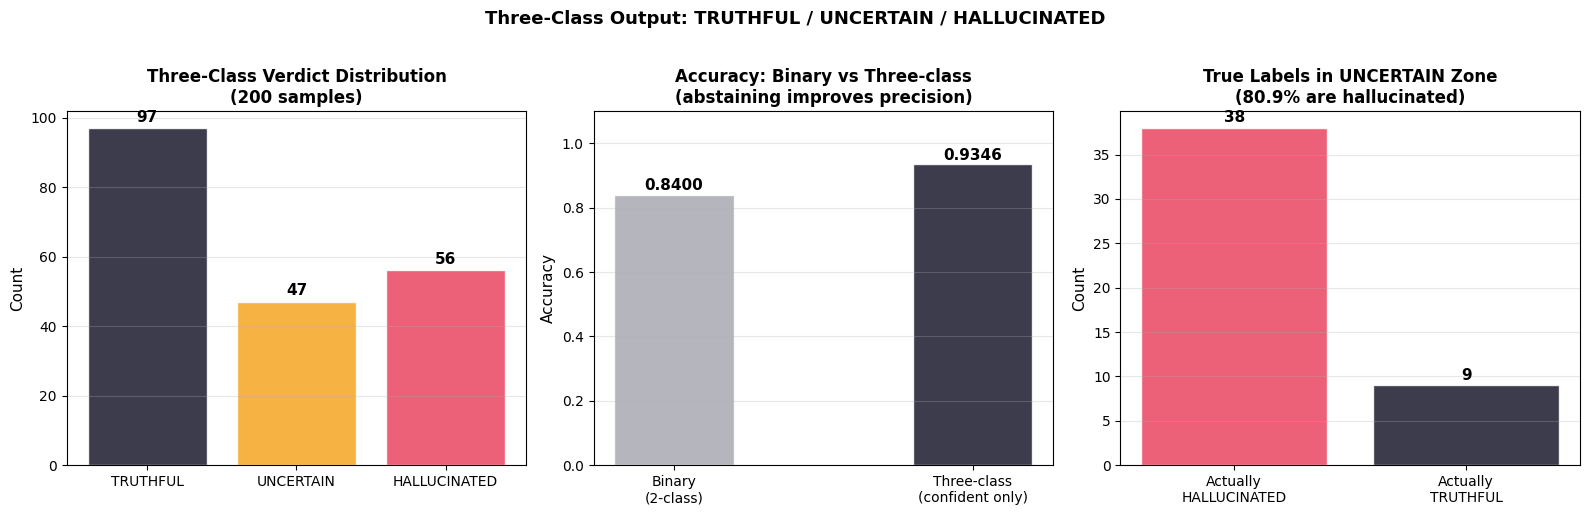

Saved to outputs/three_class_results.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Verdict distribution
colors = ['#1a1a2e', '#f5a623', '#e94560']
verdicts = ['TRUTHFUL', 'UNCERTAIN', 'HALLUCINATED']
counts = [97, 47, 56]
axes[0].bar(verdicts, counts, color=colors, alpha=0.85, edgecolor='white')
for i, (v, c) in enumerate(zip(verdicts, counts)):
    axes[0].text(i, c + 1, str(c), ha='center', va='bottom',
                fontsize=11, fontweight='bold')
axes[0].set_title('Three-Class Verdict Distribution\n(200 samples)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Accuracy comparison: binary vs three-class
systems = ['Binary\n(2-class)', 'Three-class\n(confident only)']
accuracies = [0.8400, 0.9346]
bar_colors = ['#a8a8b3', '#1a1a2e']
bars = axes[1].bar(systems, accuracies, color=bar_colors, alpha=0.85,
                   edgecolor='white', width=0.4)
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{acc:.4f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')
axes[1].set_title('Accuracy: Binary vs Three-class\n(abstaining improves precision)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

# Uncertain zone analysis
uncertain_labels = ['Actually\nHALLUCINATED', 'Actually\nTRUTHFUL']
uncertain_counts = [
    int(uncertain_hallucinated * len(uncertain_df)),
    len(uncertain_df) - int(uncertain_hallucinated * len(uncertain_df))
]
axes[2].bar(uncertain_labels, uncertain_counts,
            color=['#e94560', '#1a1a2e'], alpha=0.85, edgecolor='white')
for i, c in enumerate(uncertain_counts):
    axes[2].text(i, c + 0.3, str(c), ha='center', va='bottom',
                fontsize=11, fontweight='bold')
axes[2].set_title('True Labels in UNCERTAIN Zone\n(80.9% are hallucinated)',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Three-Class Output: TRUTHFUL / UNCERTAIN / HALLUCINATED',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/three_class_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/three_class_results.png")

## Summary

The three-class system demonstrates meaningful improvement over binary classification
through principled abstention.

| Metric | Binary System | Three-class System |
|--------|--------------|-------------------|
| Coverage | 100% | 76.5% |
| Accuracy | 84.00% | 93.46% |
| F1 Score | 0.8400 | 0.9337 |
| Abstention Rate | 0% | 23.5% |

By abstaining on 23.5% of samples where confidence falls between 0.15 and 0.85,
accuracy improves from 84% to 93.5% on the remaining 76.5%.

The UNCERTAIN zone is not random noise -- 80.9% of abstained samples are
actually hallucinated, confirming that the model's uncertainty is meaningful
and that routing these cases to human review is the correct production decision.

This converts the detector from a binary classifier into an uncertainty-aware
verifier with calibrated abstention -- a meaningfully stronger system for
real-world deployment.